In [1]:
import numpy as np
import networkx as nx
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from node2vec import Node2Vec

# Spectral Sparsification

In [2]:
def spectral_sparsify(G, T):
    ### Calculate effective resistance
    n = len(G.nodes())
    m = len(G.edges())
    E = np.zeros((m, n))
    edge_idx = 0
    edges = list(G.edges())
    for edge in edges:
        E[edge_idx, edge[0]] = 1
        E[edge_idx, edge[1]] = -1
        edge_idx += 1
    
    L = E.T@E
    L_pinv = np.linalg.pinv(L)

    R = np.zeros(m)
    for row_idx in range(m):
        E_row = E[row_idx, :]
        R[row_idx] = E_row@L_pinv@E_row.T
    probs = R/R.sum()

    ### Sample edges
    sampled_edge_counts = np.random.multinomial(T, probs)
    G_sparse = nx.Graph()
    G_sparse.add_nodes_from(G.nodes())
    for i in range(len(sampled_edge_counts)):
        u, v = edges[i]
        if sampled_edge_counts[i] == 0:
            continue
        else:
            G_sparse.add_edge(u, v, weight=sampled_edge_counts[i]/(T*probs[i]))

    return G_sparse

# DP Algorithms

In [3]:
def edge_flip(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    """
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    
    return A_perturbed

In [4]:
def edge_flip_sparsified(A, epsilon):
    """
    Definition 5 from: https://arxiv.org/pdf/2105.12615
    + 
    Spectral Sparsification
    """

    ### Distribute privacy budget
    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    ### Calculate private total edge
    n = A.shape[0]
    total_possible_edges = (n**2 - n)/2
    T = int(np.clip(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1), 0, total_possible_edges))

    ### Edge Flip
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            x = np.random.binomial(n=1, p=1/(1+np.exp(epsilon_2)))
            if x == 1:
                A_perturbed[i,j] = 1 - A[i,j]
                A_perturbed[j,i] = 1 - A[i,j]
            else:
                A_perturbed[i,j] = A[i,j]
                A_perturbed[j,i] = A[i,j]
    

    ### Spectral sparsification
    G_perturbed = nx.from_numpy_array(A_perturbed)
    G_perturbed_sparsed = spectral_sparsify(G_perturbed, T)
    A_perturbed_sparsed = nx.adjacency_matrix(G_perturbed_sparsed, weight='weight')

    return A_perturbed_sparsed.toarray(), T

In [5]:
def lapgraph(A, epsilon):
    """
    Algorithm 4 from: https://arxiv.org/pdf/2108.06504
    """

    # Distribute privacy budget to 2 steps: 
    # + Adding Laplace noise to the A matrix
    # + Keeping the top cells within the perturbed matrix

    epsilon_1 = 0.01*epsilon
    epsilon_2 = epsilon - epsilon_1

    # Get DP edge count
    T = int(np.sum(A)/2 + np.random.laplace(scale=1/epsilon_1)) # Laplace noise may not be suitable for count statistics

    # Get A_perturbed with Laplace noise
    A_perturbed = np.zeros(A.shape)
    for i in range(A.shape[0]):
        for j in range(i+1, A.shape[0]):
            A_perturbed[i,j] = A[i,j] + np.random.laplace(scale=1/epsilon_2)

    mask = np.tril(np.ones(A.shape), k=0) * -10**10
    A_perturbed = A_perturbed + mask

    # Get the indices of the top T cells
    top_indices = np.unravel_index(np.argpartition(A_perturbed.flatten(), -T)[-T:], A.shape)

    # Reset all cells to 0 and set only cells in top_indices to 1
    A_perturbed = np.zeros(A.shape)
    A_perturbed[top_indices] = 1
    
    return A_perturbed + A_perturbed.T

# Experiments

## Dense SBM

## Sparse SBM

In [38]:
np.random.seed(0)
block_size = 100
num_blocks = 3
sizes = [block_size] * num_blocks

n = np.sum(sizes)
total_edges = (n**2 - n)/2
p = 1.5*n**(-0.3)
r = 0.15*n**(-0.3)
print(f"Intra prob: {p}")
print(f"Inter prob: {r}")
deepwalk_dimension=32
n_clusters = 3
sample_size = 1


probs = np.eye(num_blocks) * p + (1 - np.eye(num_blocks)) * r

# Define epsilon values to test
epsilon_values = np.logspace(-0.5, 0.5, num=12) 

# Initialize results storage
results = {
    'Edge Flip': [],
    'Edge Flip + Adjusted': [],
    'LapGraph': [],
    # 'Edge Flip + Sparse': [],
    # 'Edge Flip + Sparse + Unweighted': []
}


# Test each epsilon value
for idx, epsilon in enumerate(epsilon_values):
    print(f"Testing epsilon = {epsilon}")

    for run in range(sample_size):
        seed = run
        np.random.seed(seed)

        #### Generate the SBM graph
        G = nx.stochastic_block_model(sizes, probs, seed=seed)
        A = nx.to_numpy_array(G)
        # Get the true labels from the SBM
        true_labels = []
        for i, size in enumerate(sizes):
            true_labels.extend([i] * size)

        #### Evaluate
        
        # Edge Flip + Eigenvector + KMeans 
        A_ef = edge_flip(A, epsilon)
        # results['Edge Flip'].append(A_ef)
        eigvals, eigvecs = np.linalg.eigh(A_ef)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip'].append(nmi_score)


        # Edge Flip + Adjusted 
        A_ef_adjusted = A_ef/(np.exp(epsilon) - 1)/(np.exp(epsilon) + 1) - (1/(np.exp(epsilon) - 1)*(np.ones(n,n) - np.eye(n)))
        # results['Edge Flip + Adjusted'].append(A_ef_adjusted)
        # eigvals, eigvecs = np.linalg.eigh(A_ef_adjusted)
        # topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        # eigvecs = eigvecs[:, topk_indices]
        # kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        # cluster_labels = kmeans.fit_predict(eigvecs)
        # nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)


        spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=seed)
        cluster_labels = spectral_clustering.fit_predict(A_ef_adjusted * -1)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['Edge Flip + Adjusted'].append(nmi_score)

        # LapGraph
        A_lg = lapgraph(A, epsilon)
        # results['LapGraph'].append(A_lg)
        eigvals, eigvecs = np.linalg.eigh(A_lg)
        topk_indices = np.argsort(np.abs(eigvals))[::-1][:n_clusters]
        eigvecs = eigvecs[:, topk_indices]
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=seed)
        cluster_labels = kmeans.fit_predict(eigvecs)
        nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
        results['LapGraph'].append(nmi_score)


        # Edge Flip + Sparse
        # A_ef_sparse, _ = edge_flip_sparsified(A, epsilon)
        # results['Edge Flip + Sparse'].append(A_ef_sparse)
        # results['Edge Flip + Sparse + Unweighted'].append(1*(A_ef_sparse > 0))
        


Intra prob: 0.2709910094026613
Inter prob: 0.02709910094026613
Testing epsilon = 0.31622776601683794
Testing epsilon = 0.3898603702549073
Testing epsilon = 0.48063808630643906
Testing epsilon = 0.5925530975545678
Testing epsilon = 0.7305271542664454
Testing epsilon = 0.9006280202112786
Testing epsilon = 1.1103363181676378
Testing epsilon = 1.368874509537081
Testing epsilon = 1.6876124757881479
Testing epsilon = 2.080567538217171
Testing epsilon = 2.5650209056800457
Testing epsilon = 3.1622776601683795


In [34]:
for i in range(6):
    print(np.sum(results['Edge Flip + Adjusted'][i] > 0))

1
1
1
1
1
1


In [35]:
results

{'Edge Flip': [0.0009920231017313112,
  0.0018287876252226333,
  0.0048742141835478306,
  0.002581831995557229,
  0.10811158058518326,
  0.2298352794337845,
  0.6120121253865773,
  0.8377636395983102,
  0.966000234160485,
  1.0,
  1.0,
  1.0],
 'Edge Flip + Adjusted': [0.0010580206278264451,
  0.0013814155695056124,
  0.00747801662336737,
  0.0651971875874745,
  0.16565382636979634,
  0.33180420531709465,
  0.6138710463700427,
  0.8361559152249783,
  0.966000234160485,
  1.0,
  1.0,
  1.0],
 'LapGraph': [0.005493596826064454,
  0.005285066628430354,
  0.004063451641241336,
  0.0028330251129378755,
  0.00830043885584234,
  0.013360200198937657,
  0.01860655151312858,
  0.08461367517461776,
  0.23434953486794372,
  0.8488375890418014,
  0.9531513473275895,
  0.9829929733076642]}

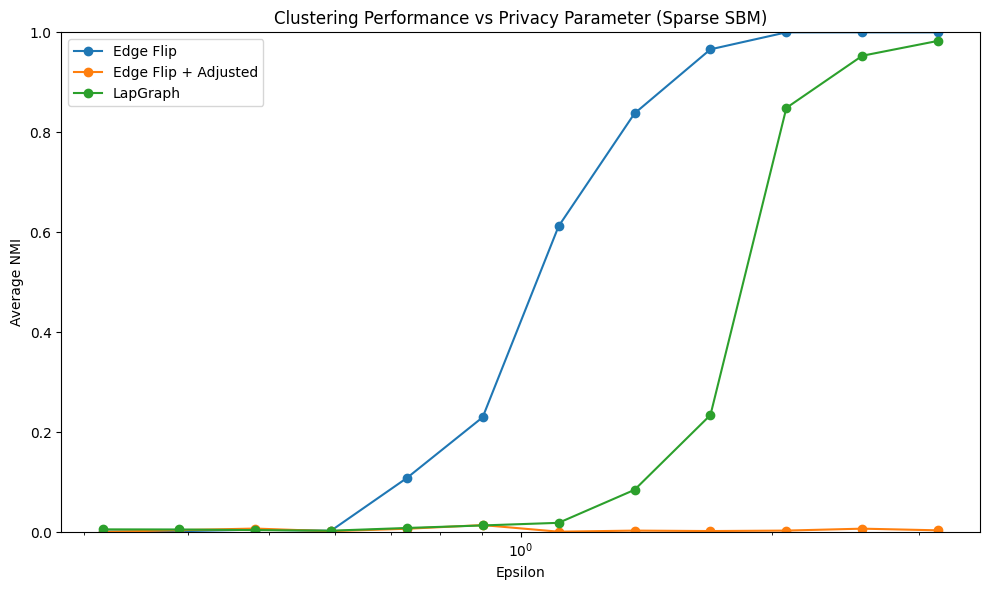

In [39]:
### Plotting NMI

# Compute mean and std for each method at each epsilon
# method_means = {}
# method_stds = {}
# for method in results:
#     means = []
#     stds = []
#     for j, eps in enumerate(epsilon_values):
#         nmi_scores = [v for v in results[method][j] if v is not None]
#         if len(nmi_scores) > 0:
#             means.append(np.mean(nmi_scores))
#             stds.append(np.std(nmi_scores, ddof=1)/np.sqrt(sample_size))
#         else:
#             means.append(np.nan)
#             stds.append(np.nan)
#     method_means[method] = means
#     method_stds[method] = stds

# Plot
plt.figure(figsize=(10, 6))
for i, method in enumerate(results.keys()):
    means = results[method] # method_means[method]
    # stds = method_stds[method]
    plt.errorbar(
        [float(e) for e in epsilon_values], 
        means, 
        # yerr=stds, 
        label=method, 
        marker='o', 
        capsize=4, 
        linestyle='-'
    )

plt.xscale('log')
plt.ylim(0,1)
plt.xlabel('Epsilon')
plt.ylabel('Average NMI')
plt.title('Clustering Performance vs Privacy Parameter (Sparse SBM)')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
results.keys()

dict_keys(['Edge Flip', 'Edge Flip + Adjusted', 'LapGraph', 'Edge Flip + Sparse', 'Edge Flip + Sparse + Unweighted'])

## Node degrees

### RMSE

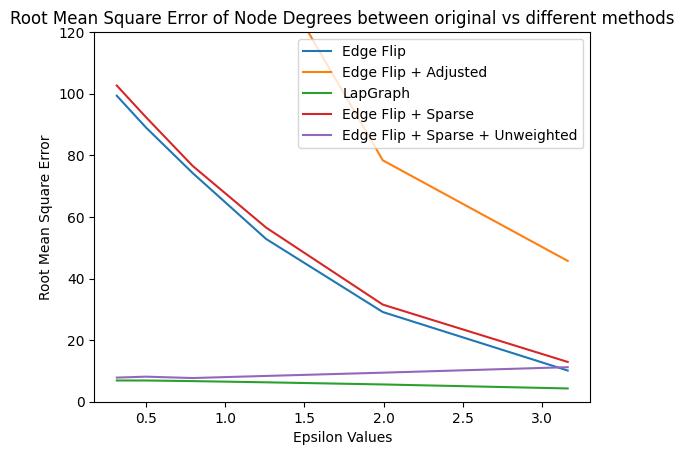

In [92]:
orig_degrees = np.sum(A, axis=1)

arr1 = orig_degrees

for method in results.keys():
    
    errors = []
    for i, adj in enumerate(results[method]):
        arr2 = np.sum(adj, axis=1)
        errors.append(np.sqrt(np.mean(np.square(arr1 - arr2))))
    
    plt.plot(epsilon_values, errors, label=method)

plt.ylim(top = 120, bottom=0)
plt.ylabel('Root Mean Square Error')
plt.xlabel('Epsilon Values')

plt.title('Root Mean Square Error of Node Degrees between original vs different methods')
plt.legend();

In [94]:
for i in range(6):
    print(np.sqrt(np.mean(np.square(arr1 - np.sum(results['LapGraph'][i], axis=1)))))

6.894442206105824
6.891540708240308
6.69377820566731
6.300793600809346
5.608327142146162
4.310452412450461


### QQ Plots

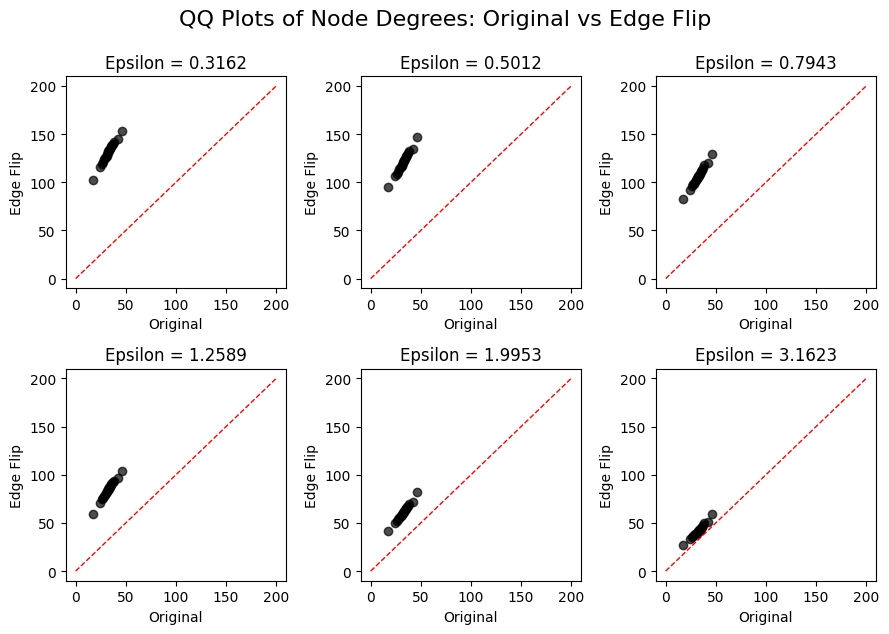

In [95]:
orig_degrees = np.sum(A, axis=1)

label1 = 'Original'
label2 = 'Edge Flip'

arr1 = orig_degrees

# INSERT_YOUR_CODE
# Plot 6 QQ plots as subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
quantiles = np.linspace(0, 1, 21)
q1 = np.quantile(arr1, quantiles)
for i, adj in enumerate(results[label2]):
    arr2 = np.sum(adj, axis=1)
    ax = axes[i // 3, i % 3]
    q2 = np.quantile(arr2, quantiles)
    ax.scatter(q1, q2, color='k', alpha=0.7)
    min_val = 0
    max_val = 200 
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)

    ax.set_title(f'Epsilon = {epsilon_values[i]:.4f}')
    
plt.tight_layout()
# INSERT_YOUR_CODE
fig.suptitle(f'QQ Plots of Node Degrees: Original vs {label2}', fontsize=16, y=1.05)

plt.show()


Text(0.5, 1.05, 'QQ Plots of Node Degrees: Original vs Edge Flip + Adjusted')

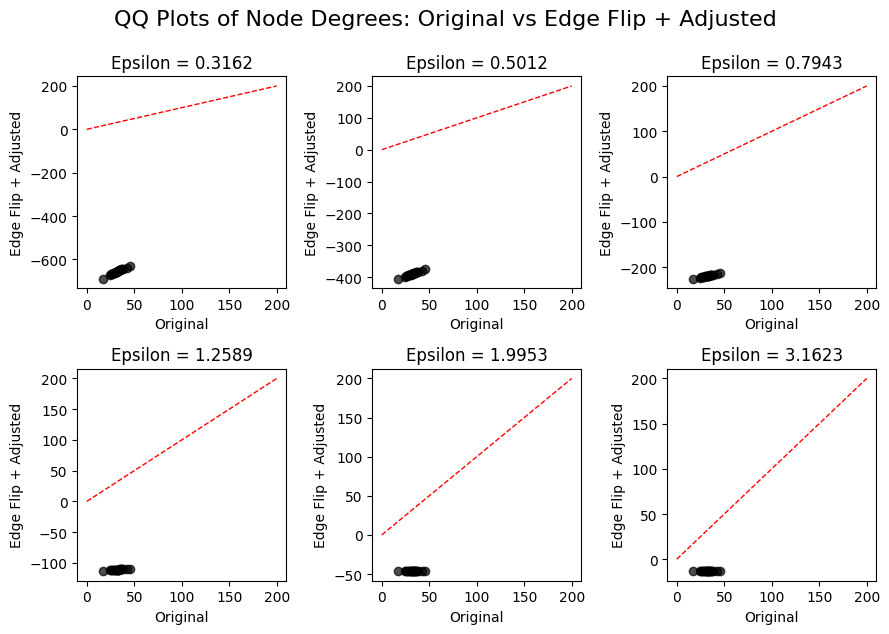

In [96]:
orig_degrees = np.sum(A, axis=1)

label1 = 'Original'
label2 = 'Edge Flip + Adjusted'

arr1 = orig_degrees

# INSERT_YOUR_CODE
# Plot 6 QQ plots as subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
quantiles = np.linspace(0, 1, 21)
q1 = np.quantile(arr1, quantiles)
for i, adj in enumerate(results[label2]):
    arr2 = np.sum(adj, axis=1)
    ax = axes[i // 3, i % 3]
    q2 = np.quantile(arr2, quantiles)
    ax.scatter(q1, q2, color='k', alpha=0.7)
    min_val = 0
    max_val = 200 
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)

    ax.set_title(f'Epsilon = {epsilon_values[i]:.4f}')
    
plt.tight_layout()
# INSERT_YOUR_CODE
fig.suptitle(f'QQ Plots of Node Degrees: Original vs {label2}', fontsize=16, y=1.05)

Text(0.5, 1.05, 'QQ Plots of Node Degrees: Original vs LapGraph')

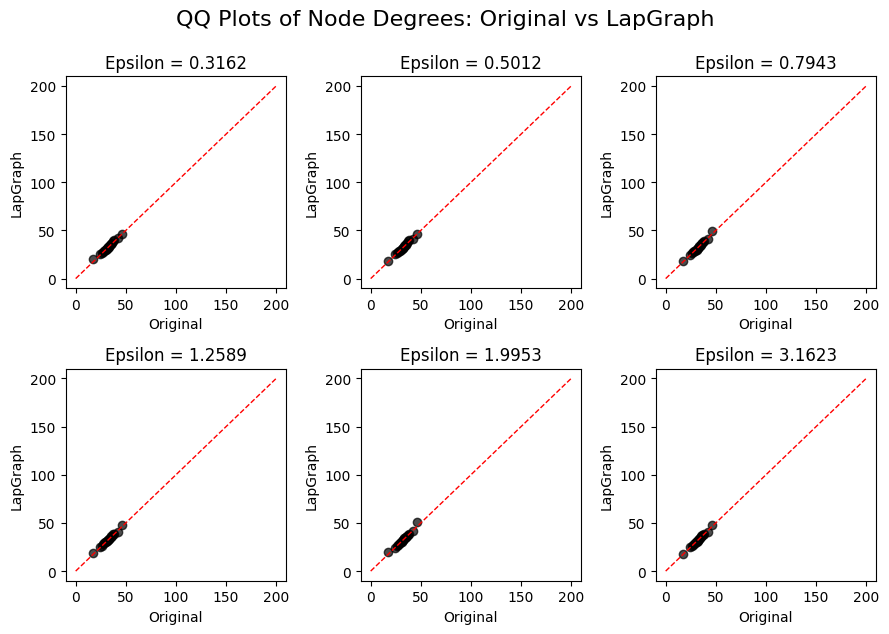

In [97]:
orig_degrees = np.sum(A, axis=1)

label1 = 'Original'
label2 = 'LapGraph'

arr1 = orig_degrees

# INSERT_YOUR_CODE
# Plot 6 QQ plots as subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
quantiles = np.linspace(0, 1, 21)
q1 = np.quantile(arr1, quantiles)
for i, adj in enumerate(results[label2]):
    arr2 = np.sum(adj, axis=1)
    ax = axes[i // 3, i % 3]
    q2 = np.quantile(arr2, quantiles)
    ax.scatter(q1, q2, color='k', alpha=0.7)
    min_val = 0
    max_val = 200 
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)

    ax.set_title(f'Epsilon = {epsilon_values[i]:.4f}')
    
plt.tight_layout()
# INSERT_YOUR_CODE
fig.suptitle(f'QQ Plots of Node Degrees: Original vs {label2}', fontsize=16, y=1.05)

Text(0.5, 1.05, 'QQ Plots of Node Degrees: Original vs Edge Flip + Sparse')

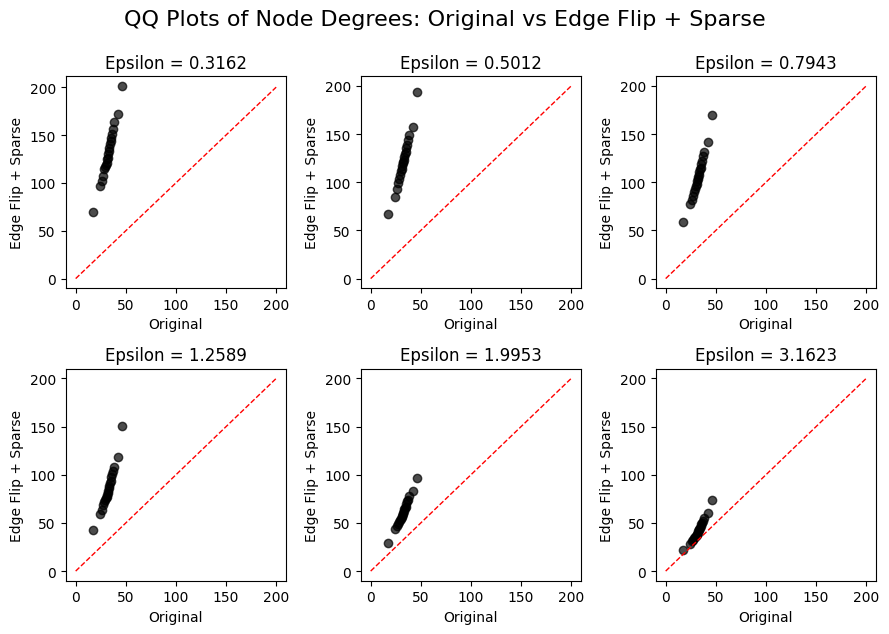

In [99]:
orig_degrees = np.sum(A, axis=1)

label1 = 'Original'
label2 = 'Edge Flip + Sparse'

arr1 = orig_degrees

# INSERT_YOUR_CODE
# Plot 6 QQ plots as subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
quantiles = np.linspace(0, 1, 21)
q1 = np.quantile(arr1, quantiles)
for i, adj in enumerate(results[label2]):
    arr2 = np.sum(adj, axis=1)
    ax = axes[i // 3, i % 3]
    q2 = np.quantile(arr2, quantiles)
    ax.scatter(q1, q2, color='k', alpha=0.7)
    min_val = 0
    max_val = 200 
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)

    ax.set_title(f'Epsilon = {epsilon_values[i]:.4f}')
    
plt.tight_layout()
# INSERT_YOUR_CODE
fig.suptitle(f'QQ Plots of Node Degrees: Original vs {label2}', fontsize=16, y=1.05)

Text(0.5, 1.05, 'QQ Plots of Node Degrees: Original vs Edge Flip + Sparse + Unweighted')

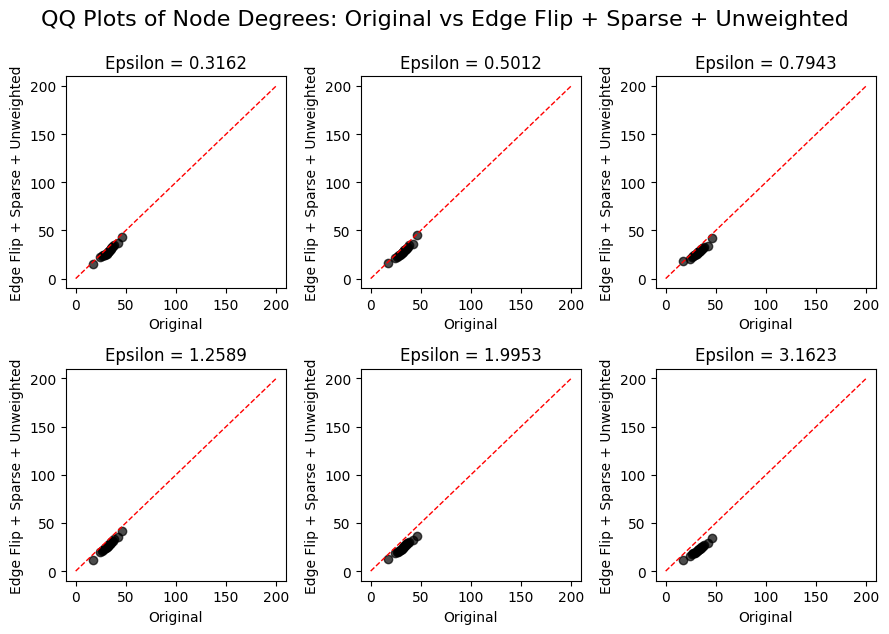

In [100]:
orig_degrees = np.sum(A, axis=1)

label1 = 'Original'
label2 = 'Edge Flip + Sparse + Unweighted'

arr1 = orig_degrees

# INSERT_YOUR_CODE
# Plot 6 QQ plots as subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
quantiles = np.linspace(0, 1, 21)
q1 = np.quantile(arr1, quantiles)
for i, adj in enumerate(results[label2]):
    arr2 = np.sum(adj, axis=1)
    ax = axes[i // 3, i % 3]
    q2 = np.quantile(arr2, quantiles)
    ax.scatter(q1, q2, color='k', alpha=0.7)
    min_val = 0
    max_val = 200 
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)

    ax.set_title(f'Epsilon = {epsilon_values[i]:.4f}')
    
plt.tight_layout()
# INSERT_YOUR_CODE
fig.suptitle(f'QQ Plots of Node Degrees: Original vs {label2}', fontsize=16, y=1.05)

## Eigenvector centrality

In [108]:
def compute_eigenvector_centrality(A):
    # Compute eigenvector centrality of adjacency matrix A
    eigvals, eigvecs = np.linalg.eig(A)
    # Find the index of the largest eigenvalue (by magnitude)
    max_idx = np.argmax(eigvals)
    # The corresponding eigenvector is the eigenvector centrality
    eigenvector_centrality = eigvecs[:, max_idx]
    # Normalize for interpretability
    eigenvector_centrality = eigenvector_centrality / np.sum(eigenvector_centrality)

    return eigenvector_centrality

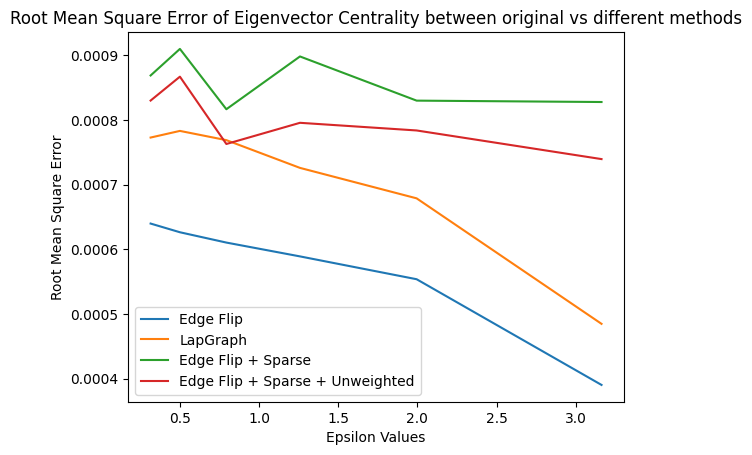

In [109]:
orig_centralites = compute_eigenvector_centrality(A)

arr1 = orig_centralites

for method in results.keys():
    if method == 'Edge Flip + Adjusted':
        continue
    
    errors = []
    for i, adj in enumerate(results[method]):
        arr2 = compute_eigenvector_centrality(adj)
        errors.append(np.sqrt(np.mean(np.square(arr1 - arr2))))
    
    plt.plot(epsilon_values, errors, label=method)

# plt.ylim(top = 120, bottom=0)
plt.ylabel('Root Mean Square Error')
plt.xlabel('Epsilon Values')

plt.title('Root Mean Square Error of Eigenvector Centrality between original vs different methods')
plt.legend();